In [1]:
from llava.model.builder import load_pretrained_model
from llava.mm_utils import get_model_name_from_path, process_images, tokenizer_image_token
from llava.constants import IMAGE_TOKEN_INDEX, DEFAULT_IMAGE_TOKEN, DEFAULT_IM_START_TOKEN, DEFAULT_IM_END_TOKEN, IGNORE_INDEX
from llava.conversation import conv_templates, SeparatorStyle

from PIL import Image
import requests
import copy
import torch

import sys
import warnings

# Load model
pretrained = "lmms-lab/llava-onevision-qwen2-0.5b-ov"
model_name = "llava_qwen"
device = "cuda"
device_map = "cuda:0"
llava_model_args = {
        "multimodal": True,
    }
overwrite_config = {}
overwrite_config["image_aspect_ratio"] = "pad"
llava_model_args["overwrite_config"] = overwrite_config
tokenizer, model, image_processor, max_length = load_pretrained_model(pretrained, None, model_name, device_map=device_map, **llava_model_args)

model.eval()
model.to(device_map)

# Load images from local directory
image1 = Image.open("/mnt/disk1/sjw/LLaVA-NeXT/image1.png")
image2 = Image.open("/mnt/disk1/sjw/LLaVA-NeXT/image2.png")

# Process imagess
images = [image1, image2]
image_tensors = process_images(images, image_processor, model.config)
image_tensors = [_image.to(dtype=torch.float16, device=device) for _image in image_tensors]

# Prepare interleaved text-image input
conv_template = "qwen_1_5"
question = f"{DEFAULT_IMAGE_TOKEN} This is the first image. \n\n This is the second image :{DEFAULT_IMAGE_TOKEN} What animal should come on top of a towering skyscraper in the second image? \n."

conv = copy.deepcopy(conv_templates[conv_template])
conv.append_message(conv.roles[0], question)
conv.append_message(conv.roles[1], None)
prompt_question = conv.get_prompt()

input_ids = tokenizer_image_token(prompt_question, tokenizer, IMAGE_TOKEN_INDEX, return_tensors="pt").unsqueeze(0).to(device_map)
image_sizes = [image.size for image in images]


Please install pyav to use video processing functions.
OpenCLIP not installed
Loaded LLaVA model: lmms-lab/llava-onevision-qwen2-0.5b-ov


You are using a model of type llava to instantiate a model of type llava_qwen. This is not supported for all configurations of models and can yield errors.


Overwriting config with {'image_aspect_ratio': 'pad'}
Loading vision tower: google/siglip-so400m-patch14-384


/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/torch/nn/modules/module.py:2068: UserWarning: for vision_model.embeddings.patch_embedding.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta parameter in the checkpoint to a meta '
/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/torch/nn/modules/module.py:2068: UserWarning: for vision_model.embeddings.patch_embedding.bias: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(f'for {key}: copying from a non-meta 

Model Class: LlavaQwenForCausalLM


In [2]:
# Generate response
cont = model.generate(
    input_ids,
    images=image_tensors,
    image_sizes=image_sizes,
    do_sample=False,
    temperature=0,
    max_new_tokens=4096,
)
text_outputs = tokenizer.batch_decode(cont, skip_special_tokens=True)
print(text_outputs[0])

/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:567: UserWarning: `do_sample` is set to `False`. However, `temperature` is set to `0` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `temperature`.
  warnings.warn(
/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:572: UserWarning: `do_sample` is set to `False`. However, `top_p` is set to `0.8` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_p`.
  warnings.warn(
/home/jjh_test/anaconda3/envs/torch2/lib/python3.10/site-packages/transformers/generation/configuration_utils.py:589: UserWarning: `do_sample` is set to `False`. However, `top_k` is set to `20` -- this flag is only used in sample-based generation modes. You should set `do_sample=True` or unset `top_k`.
  warnings.warn(
The attention mask is not

A gorilla


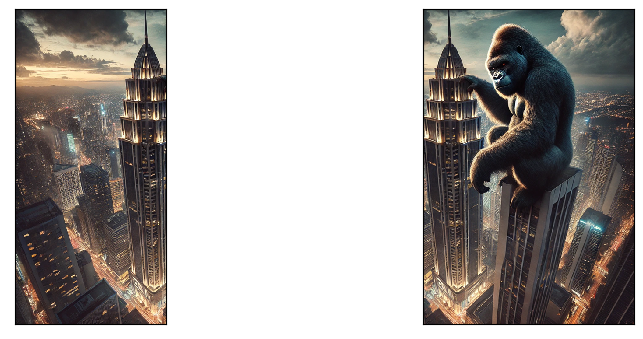

In [3]:
import matplotlib.pyplot as plt
from PIL import Image

def plot_images(images):
    images_shown = 0
    plt.figure(figsize=(16, 9))
    
    for image in images:
        if isinstance(image, Image.Image):
            plt.subplot(2, 3, images_shown + 1)
            plt.imshow(image)
            plt.xticks([])
            plt.yticks([])

            images_shown += 1
            if images_shown >= 6:  # Limiting to 6 images for the 2x3 grid
                break

    plt.show()

plot_images(images)